# Task 5 v3 — Log1p(distance_to_goal) + RobustScaler vs RobustScaler thường

**Câu hỏi:** `kmeans_v2.ipynb` đã dùng RobustScaler (median/IQR) làm nhánh chính thức, nhưng
chưa kiểm tra/xử lý độ lệch (skew) của `distance_to_goal` — feature hình học duy nhất có khả
năng lệch phải mạnh (giống `statsbomb_xg`, đa số sút gần khung thành, ít cú sút xa kéo đuôi dài).
RobustScaler làm giảm ảnh hưởng của outlier lên **độ lớn**, nhưng **không** đổi **hình dạng**
phân phối — nếu `distance_to_goal` thật sự lệch mạnh, log1p transform trước khi scale có thể
giúp K-Means tách cụm tốt hơn ở trục này.

Notebook này **độc lập** với `kmeans_v2.ipynb` (tự đọc raw CSV, tự tính scaler, không phụ thuộc
file `X_*.csv` đã xử lý sẵn) — để cô lập đúng 1 biến thí nghiệm: **có log1p hay không**, mọi thứ
khác (feature set, K range, random_state, n_init, distance metric) giữ nguyên giữa 2 nhánh
(ADR-009/010).

**Khác biệt quan trọng so với `kmeans_v2.ipynb`:** notebook này **lọc penalty/luân lưu** (ADR-004,
`shot_type == "Penalty"` hoặc `period == 5`) trước khi phân cụm — v1/v2 chưa làm việc này, dẫn
tới 1 cụm giả "penalty" (freeze_frame trống, `n_teammates_in_frame ≈ 0`) như đã thấy ở centroid
cụm 4 của `05-preprocessing.ipynb`. Không lọc trước sẽ làm nhiễu kết quả so sánh log vs không-log.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "/kaggle/working"  # doi lai neu chay o noi khac

RAW_CSV_CANDIDATES = [
    f"{DATA_DIR}/shots_worldcup_2018_2022_raw.csv",
    f"{DATA_DIR}/extract_feature_worldcup_2018_2022_raw.csv",
    "shots_worldcup_2018_2022_raw.csv",
    "extract_feature_worldcup_2018_2022_raw.csv",
    "/kaggle/input/datasets/tunlcvcng/raw-wc2018-2022/extract_feature_worldcup_2018_2022_raw.csv",
]

df_raw = None
used_path = None
for candidate in RAW_CSV_CANDIDATES:
    try:
        df_raw = pd.read_csv(candidate, encoding="utf-8-sig")
        used_path = candidate
        break
    except FileNotFoundError:
        continue

if df_raw is None:
    raise FileNotFoundError(
        f"Khong tim thay file raw shot nao trong: {RAW_CSV_CANDIDATES}. "
        "Sua RAW_CSV_CANDIDATES cho dung ten/duong dan file ban dang co tren Kaggle."
    )

print(f"Da nap: {used_path} | shape = {df_raw.shape}")
df_raw.head(3)

Da nap: /kaggle/input/datasets/tunlcvcng/raw-wc2018-2022/extract_feature_worldcup_2018_2022_raw.csv | shape = (3200, 30)


,event_id,match_id,season_id,team_id,team_name,player_id,player_name,period,minute,second,...,aerial_won,open_goal,n_teammates_in_frame,n_opponents_in_frame,keeper_x,keeper_y,end_location_x,end_location_y,outcome,statsbomb_xg
0,9d2b23a7-0fde-45f1-8b6e-58fc9da4aab5,8650,3,782,Belgium,3089,Kevin De Bruyne,1,1,34,...,False,False,4,8,118.0,41.0,120.0,34.8,Off T,0.020461
1,ff6fee87-0f6b-461e-a5fd-e5032aa19564,8650,3,781,Brazil,3295,Thiago Emiliano da Silva,1,7,12,...,False,False,4,8,118.0,38.0,120.0,35.8,Post,0.274021
2,ebeaf37c-a1be-46a4-b3bb-ae4779458734,8650,3,782,Belgium,3621,Eden Hazard,1,7,32,...,False,False,2,8,119.0,39.0,109.0,31.0,Blocked,0.065900


## 5v3.1 — Lọc penalty / luân lưu (ADR-004)

`config.EXCLUDE_SHOT_TYPES = ("Penalty",)` và `config.EXCLUDE_PERIODS = (5,)` — áp lại đúng bộ
lọc này trước khi tách feature, để cả 2 nhánh so sánh (log vs không-log) không bị nhiễu bởi cụm
giả "penalty" (toạ độ cố định, freeze_frame trống).

In [2]:
EXCLUDE_SHOT_TYPES = ("Penalty",)
EXCLUDE_PERIODS = (5,)  # luat luan luu

n_before = len(df_raw)
mask_penalty = df_raw["shot_type"].isin(EXCLUDE_SHOT_TYPES)
mask_shootout = df_raw["period"].isin(EXCLUDE_PERIODS)
mask_exclude = mask_penalty | mask_shootout

print(f"Shot bi loai vi shot_type in {EXCLUDE_SHOT_TYPES}: {int(mask_penalty.sum())}")
print(f"Shot bi loai vi period in {EXCLUDE_PERIODS} (luan luu): {int(mask_shootout.sum())}")

df = df_raw.loc[~mask_exclude].reset_index(drop=True)
print(f"Tong shot truoc loc: {n_before} -> sau loc: {len(df)} (da loai {n_before - len(df)})")

Shot bi loai vi shot_type in ('Penalty',): 132
Shot bi loai vi period in (5,) (luan luu): 80
Tong shot truoc loc: 3200 -> sau loc: 3068 (da loai 132)


## 5v3.2 — Kiểm tra độ lệch (skew) của `distance_to_goal` trước khi quyết định log transform

Đây là bước bằng chứng thực nghiệm — kiểm tra xem tiền đề "distance_to_goal bị lệch" có đúng
không, trước khi tốn công build cả 1 nhánh log transform.

Skewness distance_to_goal (goc)   : 0.448
Skewness log1p(distance_to_goal)  : -0.594

(Quy uoc doc nhanh: |skew| < 0.5 ~ gan doi xung, 0.5-1 ~ lech vua, > 1 ~ lech manh)


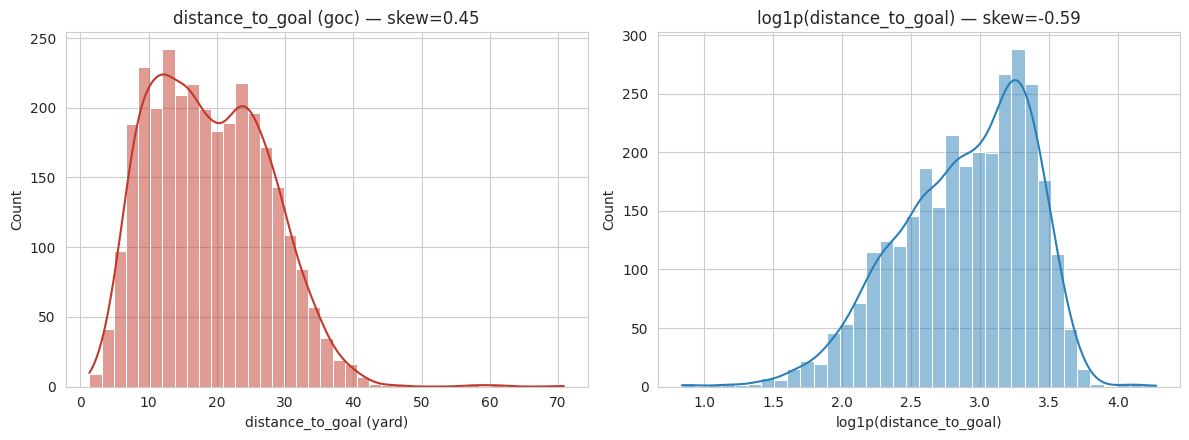

In [3]:
skew_raw = stats.skew(df["distance_to_goal"].dropna())
skew_log = stats.skew(np.log1p(df["distance_to_goal"].dropna()))

print(f"Skewness distance_to_goal (goc)   : {skew_raw:.3f}")
print(f"Skewness log1p(distance_to_goal)  : {skew_log:.3f}")
print(
    "\n(Quy uoc doc nhanh: |skew| < 0.5 ~ gan doi xung, 0.5-1 ~ lech vua, > 1 ~ lech manh)"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["distance_to_goal"], kde=True, ax=axes[0], color="#c0392b")
axes[0].set_title(f"distance_to_goal (goc) — skew={skew_raw:.2f}")
axes[0].set_xlabel("distance_to_goal (yard)")

sns.histplot(np.log1p(df["distance_to_goal"]), kde=True, ax=axes[1], color="#2980b9")
axes[1].set_title(f"log1p(distance_to_goal) — skew={skew_log:.2f}")
axes[1].set_xlabel("log1p(distance_to_goal)")

plt.tight_layout()
plt.show()

## 5v3.3 — Xây dựng feature matrix

Giữ đúng `FEATURE_COLS` như `kmeans_v2.ipynb` (distance_to_goal, angle_to_goal,
n_opponents_in_frame, n_teammates_in_frame, under_pressure, one-hot `body_part`) — chỉ thêm
đúng 1 biến thí nghiệm là log1p ở bước scale, không đổi feature set để giữ so sánh công bằng.

In [4]:
BASE_FEATURE_COLS = [
    "distance_to_goal", "angle_to_goal", "n_opponents_in_frame", "n_teammates_in_frame", "under_pressure",
]

df_encoded = pd.get_dummies(df, columns=["body_part"], drop_first=False)
body_part_cols = sorted([c for c in df_encoded.columns if c.startswith("body_part_")])
print("Cac cot body_part sau one-hot:", body_part_cols)

FEATURE_COLS = BASE_FEATURE_COLS + body_part_cols

df_encoded["under_pressure"] = df_encoded["under_pressure"].astype(int)
for c in body_part_cols:
    df_encoded[c] = df_encoded[c].astype(int)

X_unscaled_features = df_encoded[FEATURE_COLS].copy()

n_missing = X_unscaled_features.isna().sum()
print("\nMissing con lai (can xu ly truoc khi scale):")
print(n_missing[n_missing > 0] if n_missing.sum() > 0 else "khong co")

print("\nX_unscaled_features shape:", X_unscaled_features.shape)
print("FEATURE_COLS:", FEATURE_COLS)

Cac cot body_part sau one-hot: ['body_part_Head', 'body_part_Left Foot', 'body_part_Other', 'body_part_Right Foot']

Missing con lai (can xu ly truoc khi scale):
khong co

X_unscaled_features shape: (3068, 9)
FEATURE_COLS: ['distance_to_goal', 'angle_to_goal', 'n_opponents_in_frame', 'n_teammates_in_frame', 'under_pressure', 'body_part_Head', 'body_part_Left Foot', 'body_part_Other', 'body_part_Right Foot']


## 5v3.4 — Hai nhánh so sánh: `RobustScaler` thường vs `Log1p(distance_to_goal) + RobustScaler`

Cả 2 nhánh đều fit `RobustScaler` trên **cùng** `X_unscaled_features` — khác đúng 1 chỗ: nhánh
thứ 2 thay `distance_to_goal` bằng `log1p(distance_to_goal)` trước khi scale.

In [5]:
X_robust = RobustScaler().fit_transform(X_unscaled_features)

X_log_features = X_unscaled_features.copy()
X_log_features["distance_to_goal"] = np.log1p(X_log_features["distance_to_goal"])
X_log_robust = RobustScaler().fit_transform(X_log_features)

X_versions = {
    "RobustScaler": X_robust,
    "Log+RobustScaler": X_log_robust,
}

for name, X in X_versions.items():
    print(name, X.shape)

RobustScaler (3068, 9)
Log+RobustScaler (3068, 9)


## 5v3.5 — Elbow Method (kneedle, song song 2 nhánh)

Elbow k (kneedle) theo tung nhanh: {'RobustScaler': 5, 'Log+RobustScaler': 5}


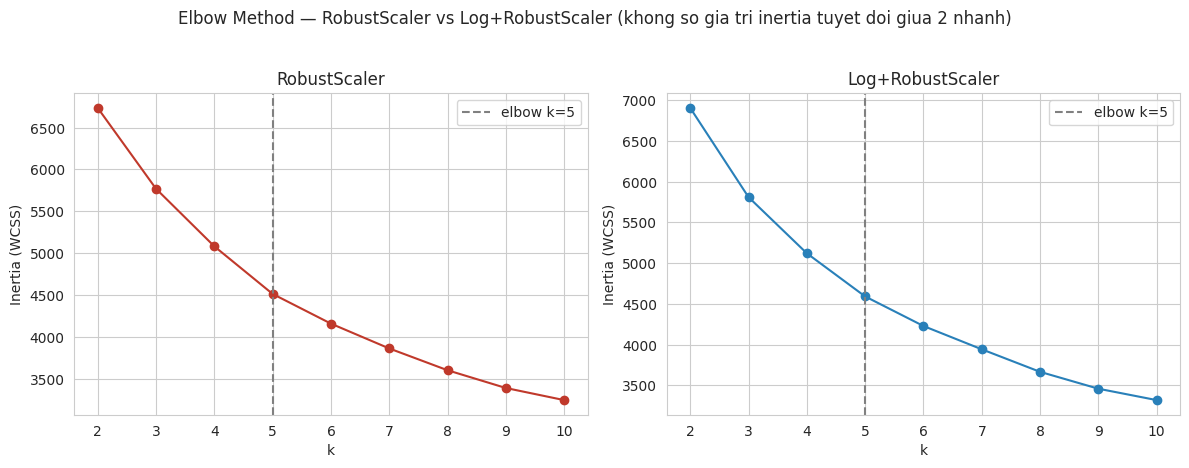

In [6]:
K_RANGE = list(range(2, 11))
colors = {"RobustScaler": "#c0392b", "Log+RobustScaler": "#2980b9"}


def kneedle_elbow(k_values, values):
    k = np.array(k_values, dtype=float)
    y = np.array(values, dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    x1, y1 = k_norm[0], y_norm[0]
    x2, y2 = k_norm[-1], y_norm[-1]
    num = np.abs((y2 - y1) * k_norm - (x2 - x1) * y_norm + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    idx = np.argmax(dist)
    return int(k[idx])


inertia_results = {}
for name, X in X_versions.items():
    inertias = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    inertia_results[name] = inertias

elbow_k = {name: kneedle_elbow(K_RANGE, vals) for name, vals in inertia_results.items()}
print("Elbow k (kneedle) theo tung nhanh:", elbow_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for ax, name in zip(axes, X_versions.keys()):
    ax.plot(K_RANGE, inertia_results[name], marker="o", color=colors[name])
    ax.axvline(elbow_k[name], linestyle="--", color="gray", label=f"elbow k={elbow_k[name]}")
    ax.set_title(name)
    ax.set_xlabel("k")
    ax.set_ylabel("Inertia (WCSS)")
    ax.legend()

plt.suptitle("Elbow Method — RobustScaler vs Log+RobustScaler (khong so gia tri inertia tuyet doi giua 2 nhanh)", y=1.03)
plt.tight_layout()
plt.show()

## 5v3.6 — Silhouette Score (song song 2 nhánh)

Best k theo Silhouette: {'RobustScaler': 2, 'Log+RobustScaler': 2}


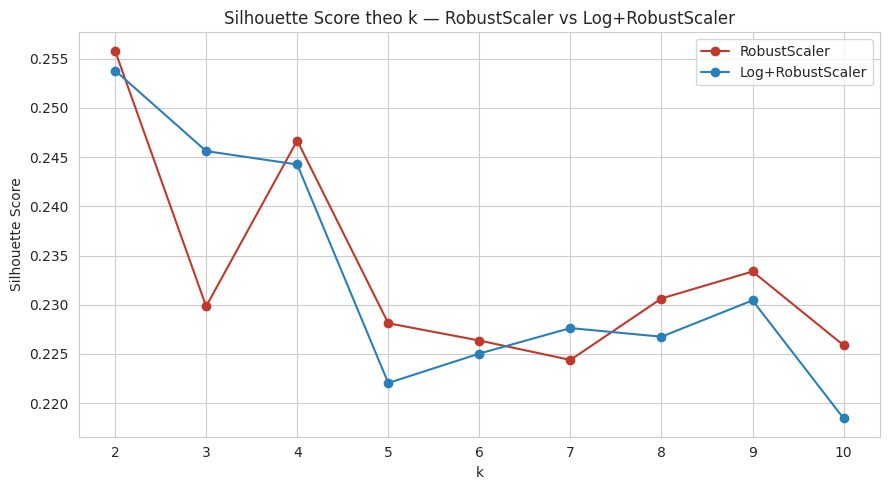

In [7]:
silhouette_results = {}
for name, X in X_versions.items():
    sils = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    silhouette_results[name] = sils

best_k_silhouette = {name: K_RANGE[int(np.argmax(vals))] for name, vals in silhouette_results.items()}
print("Best k theo Silhouette:", best_k_silhouette)

fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in silhouette_results.items():
    ax.plot(K_RANGE, vals, marker="o", label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score theo k — RobustScaler vs Log+RobustScaler")
ax.legend()
plt.tight_layout()
plt.show()

## 5v3.7 — Gap Statistic (Tibshirani, song song 2 nhánh)

k chon theo Gap Statistic (quy tac Tibshirani): {'RobustScaler': 2, 'Log+RobustScaler': 2}


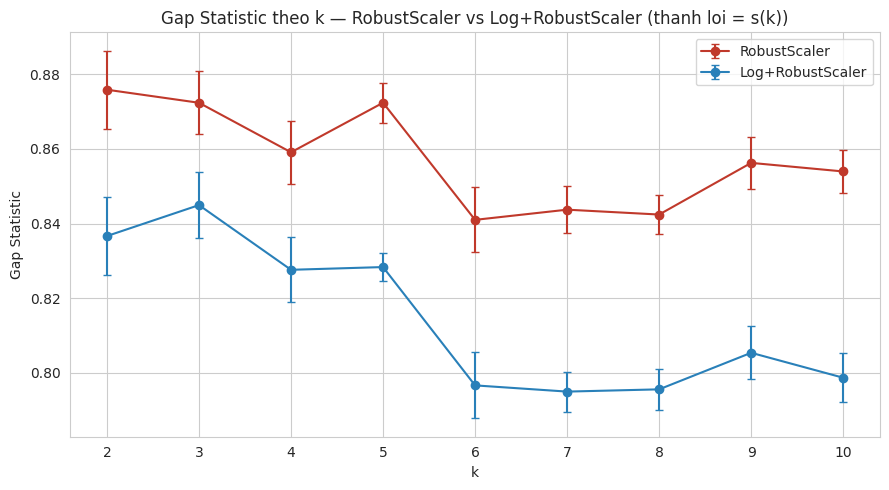

In [8]:
def compute_gap_statistic(X, k_range, B=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)

    def fit_inertia(data, k, seed):
        km = KMeans(n_clusters=k, n_init=10, random_state=seed)
        km.fit(data)
        return km.inertia_

    gaps, sks = [], []
    for k in k_range:
        wk_real = fit_inertia(X, k, random_state)

        log_wk_refs = []
        for b in range(B):
            X_ref = rng.uniform(low=mins, high=maxs, size=X.shape)
            wk_ref = fit_inertia(X_ref, k, random_state + b + 1)
            log_wk_refs.append(np.log(wk_ref))
        log_wk_refs = np.array(log_wk_refs)

        gap = log_wk_refs.mean() - np.log(wk_real)
        sk = log_wk_refs.std() * np.sqrt(1 + 1.0 / B)
        gaps.append(gap)
        sks.append(sk)

    return np.array(gaps), np.array(sks)


def choose_k_tibshirani(k_range, gaps, sks):
    for i in range(len(k_range) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_range[i]
    return None  # khong tim duoc k thoa dieu kien trong pham vi da thu


gap_results = {}
for name, X in X_versions.items():
    gaps, sks = compute_gap_statistic(X, K_RANGE, B=10, random_state=42)
    gap_results[name] = (gaps, sks)

gap_k = {name: choose_k_tibshirani(K_RANGE, gaps, sks) for name, (gaps, sks) in gap_results.items()}
print("k chon theo Gap Statistic (quy tac Tibshirani):", gap_k)

fig, ax = plt.subplots(figsize=(9, 5))
for name, (gaps, sks) in gap_results.items():
    ax.errorbar(K_RANGE, gaps, yerr=sks, marker="o", capsize=3, label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Gap Statistic")
ax.set_title("Gap Statistic theo k — RobustScaler vs Log+RobustScaler (thanh loi = s(k))")
ax.legend()
plt.tight_layout()
plt.show()

## 5v3.8 — Bảng tổng hợp k đề xuất

In [9]:
summary_k = pd.DataFrame({
    "Elbow (kneedle)": elbow_k,
    "Silhouette (max)": best_k_silhouette,
    "Gap Statistic (Tibshirani)": gap_k,
})
summary_k

,Elbow (kneedle),Silhouette (max),Gap Statistic (Tibshirani)
RobustScaler,5,2,2
Log+RobustScaler,5,2,2


## 5v3.9 — ARI giữa 2 nhánh theo k — log transform có đổi cấu trúc cụm không?

Cố định k giống nhau cho cả 2 nhánh rồi đo Adjusted Rand Index giữa nhãn cụm — đúng phương pháp
`kmeans_v2.ipynb` đã dùng ở mục 5.5, áp cho phép so sánh "có log hay không" thay vì "scaler nào".

**Cách đọc:** ARI cao (gần 1) ⇒ log1p hầu như không đổi cách chia cụm (RobustScaler tự nó đã đủ
robust với skew, log transform gần như dư thừa). ARI thấp ⇒ log1p thực sự thay đổi cấu trúc cụm
— cần nhìn thêm silhouette/centroid để biết nhánh nào tách nhóm hợp lý hơn.

,"ARI(RobustScaler, Log+RobustScaler)"
k,
2,0.993487
3,0.857129
4,0.937408
5,0.913345
6,0.889627
7,0.679392


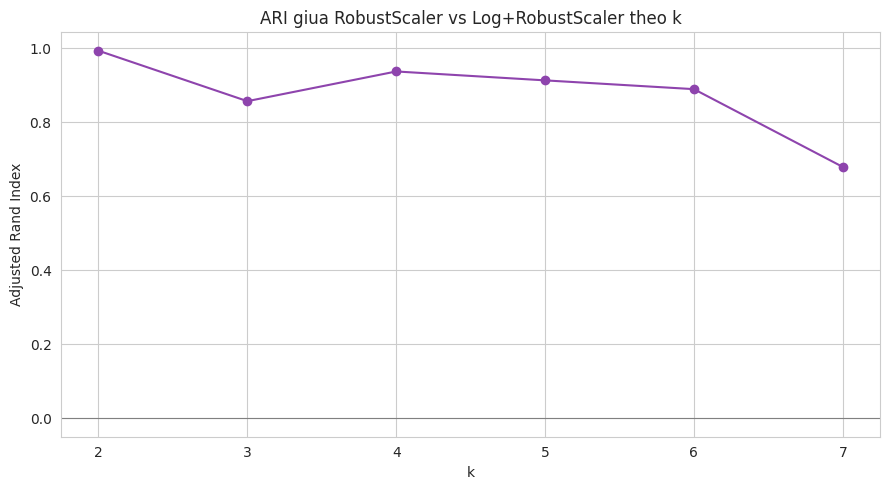

In [10]:
ari_k_range = [2, 3, 4, 5, 6, 7]
ari_rows = []
cluster_labels_by_k = {}

for k in ari_k_range:
    labels = {}
    for name, X in X_versions.items():
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels[name] = km.fit_predict(X)
    cluster_labels_by_k[k] = labels

    ari = adjusted_rand_score(labels["RobustScaler"], labels["Log+RobustScaler"])
    ari_rows.append({"k": k, "ARI(RobustScaler, Log+RobustScaler)": ari})

ari_df = pd.DataFrame(ari_rows).set_index("k")
display(ari_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ari_df.index, ari_df["ARI(RobustScaler, Log+RobustScaler)"], marker="o", color="#8e44ad")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("k")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("ARI giua RobustScaler vs Log+RobustScaler theo k")
plt.tight_layout()
plt.show()

## 5v3.10 — Chốt phương án & trực quan hoá không gian

`FINAL_K` đặt mặc định = 5 để so sánh trực tiếp với `kmeans_v2.ipynb` (đã chốt RobustScaler,
k=5) — **đổi lại giá trị này** dựa trên bảng tổng hợp và ARI ở trên nếu kết quả thực tế gợi ý
k khác.

In [11]:
FINAL_K = 5  # doi lai neu bang 5v3.8 / ARI 5v3.9 goi y k khac

labels_at_final_k = cluster_labels_by_k.get(FINAL_K)
if labels_at_final_k is None:
    labels_at_final_k = {}
    for name, X in X_versions.items():
        km = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
        labels_at_final_k[name] = km.fit_predict(X)

# Centroid luon mo ta bang feature GOC (distance_to_goal chua log) de de doc/bao cao,
# kem location_x/y (lay tu df_encoded, KHONG nam trong FEATURE_COLS dung de cluster)
# de dung cho bieu do dia ly o cell sau.
describe_cols = FEATURE_COLS + ["location_x", "location_y"]
unscaled_features_original = df_encoded[describe_cols].copy()

centroids_original = {}
for name, lbl in labels_at_final_k.items():
    tmp = unscaled_features_original.copy()
    tmp["Cluster"] = lbl
    centroids_original[name] = tmp.groupby("Cluster").mean()
    print(f"=== {name} (k={FINAL_K}) - so shot / cum ===")
    print(pd.Series(lbl).value_counts().sort_index().to_dict())

print(f"\n--- Centroid (RobustScaler, k={FINAL_K}) ---")
display(centroids_original["RobustScaler"])
print(f"\n--- Centroid (Log+RobustScaler, k={FINAL_K}) ---")
display(centroids_original["Log+RobustScaler"])

=== RobustScaler (k=5) - so shot / cum ===
{0: 555, 1: 654, 2: 762, 3: 567, 4: 530}
=== Log+RobustScaler (k=5) - so shot / cum ===
{0: 568, 1: 626, 2: 556, 3: 565, 4: 753}

--- Centroid (RobustScaler, k=5) ---


,distance_to_goal,angle_to_goal,n_opponents_in_frame,n_teammates_in_frame,under_pressure,body_part_Head,body_part_Left Foot,body_part_Other,body_part_Right Foot,location_x,location_y
Cluster,,,,,,,,,,,
0,15.767409,0.000770,6.194595,2.383784,0.181982,0.127928,0.309910,0.009009,0.553153,107.566486,40.315135
1,27.713693,0.044475,10.524465,6.935780,0.084098,0.000000,0.264526,0.000000,0.735474,95.294648,38.883486
2,19.394264,-0.045375,8.761155,4.568241,0.128609,0.000000,0.000000,0.002625,0.997375,104.162073,40.302100
3,19.688447,0.020418,8.959436,4.723104,0.142857,0.000000,1.000000,0.000000,0.000000,103.490653,40.320459
4,9.895812,-0.027498,10.028302,5.662264,0.437736,0.926415,0.018868,0.037736,0.016981,111.685094,40.367170



--- Centroid (Log+RobustScaler, k=5) ---


,distance_to_goal,angle_to_goal,n_opponents_in_frame,n_teammates_in_frame,under_pressure,body_part_Head,body_part_Left Foot,body_part_Other,body_part_Right Foot,location_x,location_y
Cluster,,,,,,,,,,,
0,20.423584,0.014730,8.978873,4.758803,0.140845,0.000000,1.000000,0.000000,0.000000,102.817606,40.297359
1,27.226749,0.031458,10.570288,7.011182,0.081470,0.007987,0.253994,0.000000,0.738019,95.778435,39.143291
2,15.747419,0.008560,6.192446,2.392086,0.178058,0.115108,0.316547,0.008993,0.559353,107.591007,40.232374
3,9.502046,-0.018270,9.980531,5.587611,0.423009,0.870796,0.033628,0.037168,0.058407,112.063717,40.273274
4,20.310045,-0.040577,8.755644,4.568393,0.130146,0.001328,0.000000,0.001328,0.997344,103.282337,40.179283


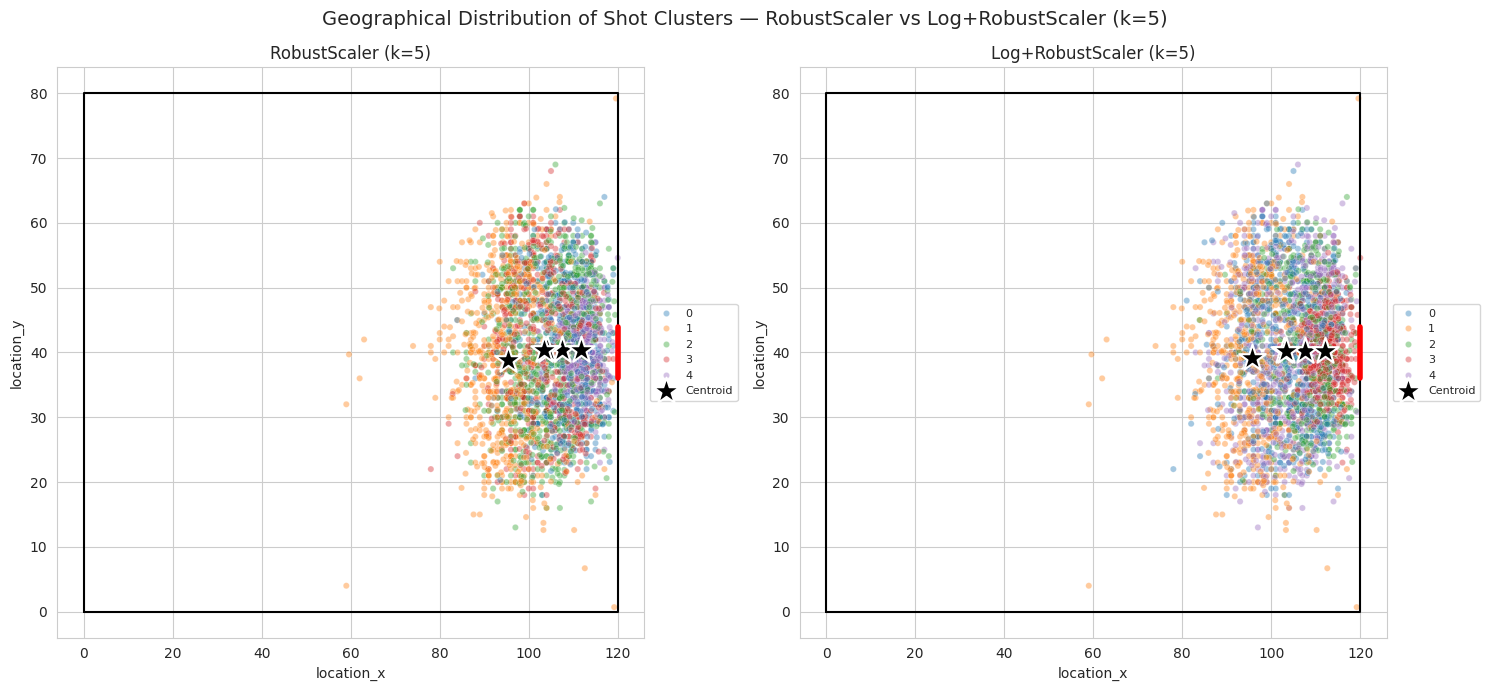

In [12]:
# Bieu do phan bo vi tri cu sut theo cum, 2 nhanh canh nhau (dung location_x/y co san trong df goc)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(f"Geographical Distribution of Shot Clusters — RobustScaler vs Log+RobustScaler (k={FINAL_K})", fontsize=14)

for ax, name in zip(axes, ["RobustScaler", "Log+RobustScaler"]):
    lbl = labels_at_final_k[name]

    sns.scatterplot(
        x=df["location_x"], y=df["location_y"],
        hue=lbl, palette="tab10", ax=ax, s=20, alpha=0.4,
    )
    ax.scatter(
        x=centroids_original[name]["location_x"], y=centroids_original[name]["location_y"],
        color="black", marker="*", s=400, edgecolor="white", linewidth=1.5, label="Centroid",
    )
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
    ax.plot([120, 120], [36, 44], color="red", linewidth=4)
    ax.set_title(f"{name} (k={FINAL_K})")
    ax.set_xlabel("location_x")
    ax.set_ylabel("location_y")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# Luu lai nhan cum ca 2 nhanh de tham khao/so sanh them o Task 6 neu can
cluster_output = df[["event_id", "match_id", "season_id", "team_name", "player_name"]].copy()
for name in X_versions:
    cluster_output[f"cluster_id_{name.replace('+', '_')}"] = labels_at_final_k[name]

out_path = f"{DATA_DIR}/shot_clusters_v3_k{FINAL_K}.csv"
cluster_output.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Da luu: {out_path}")
cluster_output.head(5)

Da luu: /kaggle/working/shot_clusters_v3_k5.csv


,event_id,match_id,season_id,team_name,player_name,cluster_id_RobustScaler,cluster_id_Log_RobustScaler
0,9d2b23a7-0fde-45f1-8b6e-58fc9da4aab5,8650,3,Belgium,Kevin De Bruyne,2,4
1,ff6fee87-0f6b-461e-a5fd-e5032aa19564,8650,3,Brazil,Thiago Emiliano da Silva,2,4
2,ebeaf37c-a1be-46a4-b3bb-ae4779458734,8650,3,Belgium,Eden Hazard,0,2
3,0f142c55-8a4a-4af1-b57b-e8eba2491c4b,8650,3,Belgium,Nacer Chadli,2,4
4,06ffa199-3887-4696-b954-5ba6376cbce6,8650,3,Brazil,José Paulo Bezzera Maciel Júnior,2,4


## Kết luận

- Mục 5v3.2 cho biết `distance_to_goal` thực sự lệch bao nhiêu (skew trước/sau log1p) — nếu skew
  gốc đã gần 0 (< 0.5), log transform gần như không cần thiết, bất kể ARI/silhouette nói gì thêm.
- Mục 5v3.9 (ARI) là bằng chứng chính: ARI cao ⇒ giữ RobustScaler thường cho đơn giản (ít bước
  biến đổi hơn, dễ diễn giải centroid hơn vì không phải quy đổi ngược log). ARI thấp ⇒ xem thêm
  silhouette ở 5v3.6 nhánh nào cao hơn ở k đã chọn, và nhìn trực quan 5v3.10 xem cụm nào tách theo
  vùng sân hợp lý hơn về mặt chiến thuật.
- Nếu quyết định đổi sang `Log+RobustScaler`, cần cập nhật `preprocess.py`/`04_preprocess_kaggle.ipynb`
  (thêm bước log1p trước `RobustScaler`) và ghi thành ADR mới — đây hiện chỉ là notebook thí
  nghiệm, chưa phải quyết định chính thức của pipeline.